In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

import matplotlib.cm as cm
import colormaps as cmaps
import matplotlib.colors as colors
from labellines import labelLines
from matplotlib.cm import brg, ScalarMappable
from matplotlib.colors import (
    LogNorm,
    TwoSlopeNorm,
    LinearSegmentedColormap,
    Normalize,
    ListedColormap,
)
from matplotlib.lines import Line2D

import jax
import jax.numpy as jnp
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import yaml
from pathlib import Path

import EI.ei_original as ut
import EI.ei_open_loop as eol
import EI.ei_unified as eu
import EI.ei_jax as ej

from utils.logger import logger, tqdm_bar

cosmetics

In [2]:
plt.rcParams.update(
    {
        "text.usetex": False,
        "font.family": "sans-serif",
        "font.sans-serif": ["Calibri"],
        "font.size": 8,
        "mathtext.fontset": "cm",
    }
)

gnuplot_barve = cm.gnuplot2_r(np.linspace(0.3, 1, 10))
gnuplot_custom = LinearSegmentedColormap.from_list("gnuplot_custom", gnuplot_barve)

brg_barve = cmaps.guppy(np.linspace(0, 1, 10))
bgr_custom = LinearSegmentedColormap.from_list("bgr_custom", brg_barve)

YlGn_barve = cm.YlGn(np.linspace(0, 0.8, 10))
ylgn_custom = LinearSegmentedColormap.from_list("ylgn_custom", YlGn_barve)

markers = ["o", "D", "^", "x", "v", "<", ">", "p", "*", "X"]

set1_list = [
    "#e41a1c",
    "#377eb8",
    "#4daf4a",
    "#984ea3",
    "#ff7f00",
    "#f781bf",
    "#999999",
    "#a65628",
]
bold_list = [
    "#7f3c8d",
    "#11a579",
    "#3969ac",
    "#e73f74",
    "#f2b701",
    "#80ba5a",
    "#e68310",
    "#008695",
    "#cf1c90",
    "#f97b72",
    "#a5aa99",
]


OUT = "/home/kzeleznikar/IJS-F1/Koda/equilibrium_EI/plots/"
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("png", dpi=300)


config

In [3]:
cfg_path = Path("config/config_eq.yaml")

with cfg_path.open("r") as f:
    cfg = yaml.safe_load(f)

md = cfg["model"]
eq = cfg["equilibrium"]

nk = md["nk"]
nt = md["nt"]
bp = md["band"]["pars"]


gap = bp["gap"]
ta = bp["ta"]
tb = bp["tb"]
v = md["mean_field"]["v"]
n = md["mean_field"]["n"]
uh = md["mean_field"]["uh"]

bd = eu.tb_2d(nk, **bp)

p = eu.MFPars(**md["mean_field"])


In [4]:
s0 = eu.solve_eq(bd, p, **eq["initial"], **eq["solve"])

d0 = abs(s0.d)
mu0 = s0.mu

# za normalizacijo
tc = eu.critical_temperature(bd, p, **eq["critical"])

logger.info(f"Delta_0 = {d0}")
logger.info(f"T_c     = {tc}")
logger.info(f"mu0     = {mu0}")

kriticna temp bisekcija:   0%|          | 0/100 [00:00<?, ?it/s]

[20:35:16] [INFO    ] Delta_0 = 1.682557551696992
[20:35:16] [INFO    ] T_c     = 0.8920595022633673
[20:35:16] [INFO    ] mu0     = 2.5000000002392047


In [5]:
va = np.linspace(0.0, 8.0, 6)
t = 0.1

# window okoli Gamma
kw = 1 * np.pi

nk1 = int(round(np.sqrt(bd.ea.size)))
c = nk1 // 2

ka = 2.0 * np.pi * (np.arange(nk1) - c) / nk1
im = np.abs(ka) <= kw
kx = ka[im]

eaa = np.empty((va.size, kx.size))
eba = np.empty_like(eaa)
da = np.empty(va.size)
mua = np.empty(va.size)

d = max(abs(s0.d), 1.0e-3)
m = s0.m

bar = tqdm(range(va.size), desc="V sweep")

for q in bar:
    v0 = va[q]

    pq = eu.MFPars(
        v=float(v0),
        n=p.n,
        uh=None,
    )

    sq = eu.solve_eq(
        bd,
        pq,
        t=t,
        d=max(abs(d), 1.0e-3),
        m=m,
        mix=(0.15, 0.15),
        tol=1.0e-7,
        nmax=20000,
        chk=20,
        prog=False,
    )

    st = ej.mf_state(
        bd,
        pq,
        sq.d,
        sq.m,
    )

    ea = np.asarray(st.e[0]).reshape(nk1, nk1)
    eb = np.asarray(st.e[1]).reshape(nk1, nk1)

    # ky = 0 and energies relative to mu
    # eaa[q] = ea[im, c] - sq.mu
    eaa[q] = ea[im, c] - sq.mu
    # eba[q] = eb[im, c] - sq.mu
    eba[q] = eb[im, c] - sq.mu

    da[q] = abs(sq.d)
    mua[q] = sq.mu

    d = sq.d
    m = sq.m

    bar.set_postfix(
        v=f"{v0:.2f}",
        d=f"{abs(sq.d):.3e}",
        mu=f"{sq.mu:.3f}",
    )

V sweep:   0%|          | 0/6 [00:00<?, ?it/s]

findfont: Failed to find font weight normal, now using 300.


Plotting:   0%|          | 0/6 [00:00<?, ?it/s]

findfont: Failed to find font weight normal, now using 300.


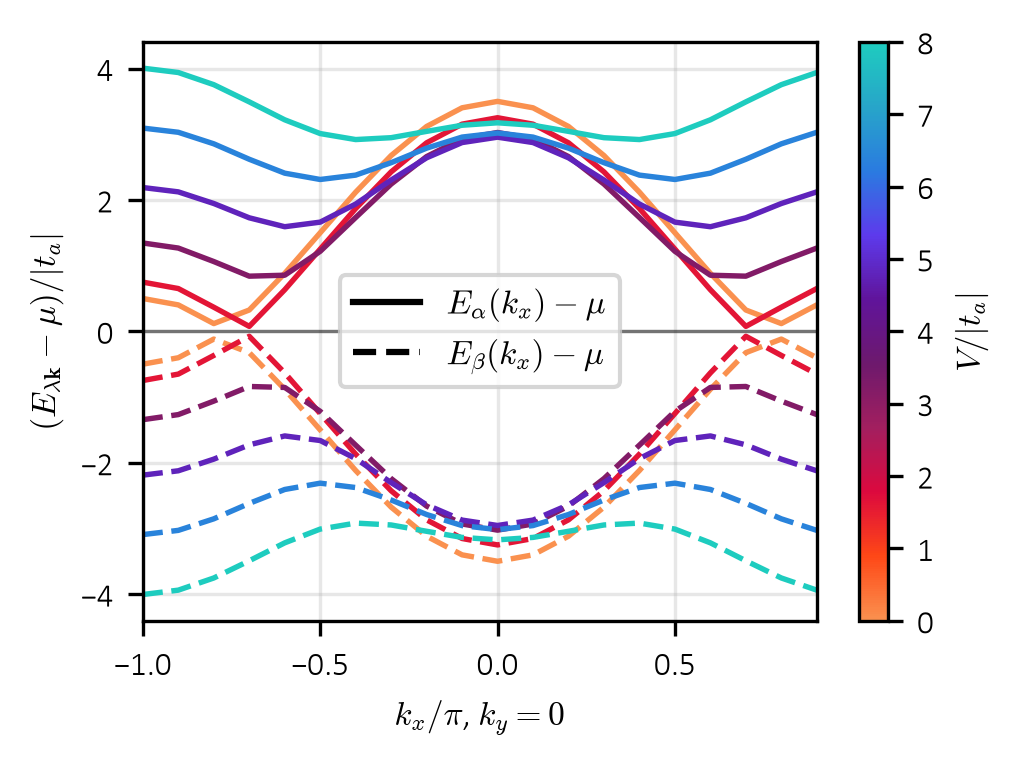

In [6]:
norm = Normalize(vmin=va.min(), vmax=va.max())
cm = bgr_custom
sm = ScalarMappable(norm=norm, cmap=cm)
sm.set_array([])

h = 0.75
fig, ax = plt.subplots(
    figsize=(3.47412, h * 3.47412)
)

for q in tqdm(range(va.size), desc="Plotting"):
    cl = cm(norm(va[q]))

    ax.plot(
        kx / np.pi,
        eaa[q],
        color=cl,
        linestyle="-",
        linewidth=1.3,
    )

    ax.plot(
        kx / np.pi,
        eba[q],
        color=cl,
        linestyle="--",
        linewidth=1.3,
    )

ax.plot(
    [],
    [],
    color="black",
    linestyle="-",
    label=r"$E_{\alpha}(k_x)-\mu$",
)

ax.plot(
    [],
    [],
    color="black",
    linestyle="--",
    label=r"$E_{\beta}(k_x)-\mu$",
)

ax.axhline(
    0.0,
    color="black",
    linewidth=0.8,
    alpha=0.5,
)

ax.set_xlim(kx[0] / np.pi, kx[-1] / np.pi)
ax.set_xlabel(r"$k_x/\pi$, $k_y=0$")
ax.set_ylabel(r"$(E_{\lambda\mathbf{k}}-\mu)/|t_a|$")

ax.grid(alpha=0.3)
ax.legend(loc="best")

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r"$V/|t_a|$", rotation=90, labelpad=5)

plt.tight_layout()
plt.show()

In [7]:
va = np.linspace(0.0, 8.0, 11)
tr = np.linspace(0.1, 0.9, 2)

da = np.empty((tr.size, va.size))
gda = np.empty_like(da)

bar = tqdm(range(tr.size), desc="Temperature sweep")

for j in bar:
    t = tr[j] * tc

    d = max(d0, 0.1)
    m = s0.m

    for q in tqdm(
        range(va.size - 1, -1, -1),
        desc=rf"$T/T_c={tr[j]:.2f}$",
        leave=False,
    ):
        v0 = va[q]

        pq = eu.MFPars(
            v=float(v0),
            n=n,
            uh=uh,
        )

        sq = eu.solve_eq(
            bd, pq, t=t,
            d=max(abs(d), 1.0e-3),
            m=m,
            **eq["solve"],
        )

        st = ej.mf_state(
            bd, pq,
            sq.d, sq.m,
        )

        ee = np.asarray(st.e)

        da[j, q] = abs(sq.d)
        gda[j, q] = 0.5 * np.min(ee[0] - ee[1])

        d = sq.d
        m = sq.m

        bar.set_postfix(
            t=f"{tr[j]:.2f}",
            v=f"{v0:.2f}",
            d=f"{abs(sq.d):.3e}",
        )

Temperature sweep:   0%|          | 0/2 [00:00<?, ?it/s]

$T/T_c=0.10$:   0%|          | 0/11 [00:00<?, ?it/s]

$T/T_c=0.90$:   0%|          | 0/11 [00:00<?, ?it/s]

Plotting:   0%|          | 0/2 [00:00<?, ?it/s]

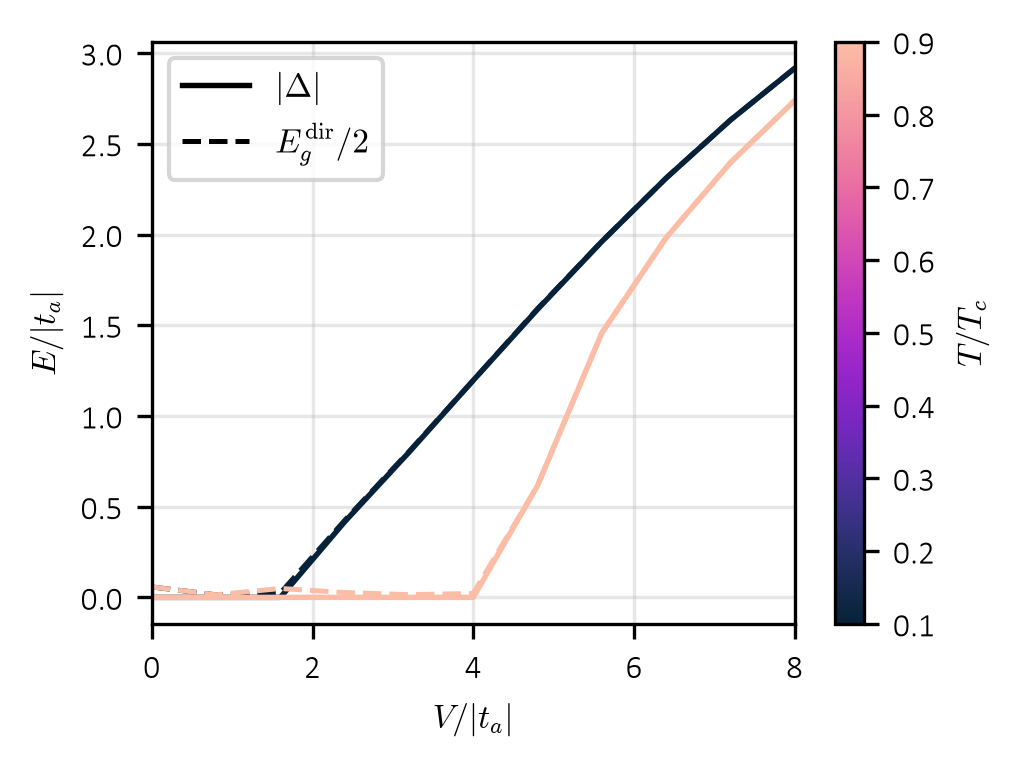

In [8]:

e0 = abs(ta)

norm = Normalize(
    vmin=tr.min(),
    vmax=tr.max(),
)

cm = cmaps.bubblegum
sm = ScalarMappable(
    norm=norm,
    cmap=cm,
)
sm.set_array([])

h = 0.75
fig, ax = plt.subplots(
    figsize=(3.47412, h * 3.47412)
)

for j in tqdm(range(tr.size), desc="Plotting"):
    cl = cm(norm(tr[j]))

    ax.plot(
        va / e0,
        da[j] / e0,
        color=cl,
        linestyle="-",
        linewidth=1.3,
    )

    ax.plot(
        va / e0,
        gda[j] / e0,
        color=cl,
        linestyle="--",
        linewidth=1.2,
    )

lh = [
    Line2D(
        [0], [0],
        color="black",
        linestyle="-",
        linewidth=1.3,
        label=r"$|\Delta|$",
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle="--",
        linewidth=1.2,
        label=r"$E_g^{\rm dir}/2$",
    ),
]

ax.set_xlim(va[0] / e0, va[-1] / e0)
ax.set_xlabel(r"$V/|t_a|$")
ax.set_ylabel(r"$E/|t_a|$")

ax.grid(alpha=0.3)

ax.legend(
    handles=lh,
    loc=2
)

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(
    r"$T/T_c$",
    rotation=90,
    labelpad=5,
)

plt.tight_layout()
plt.show()

In [9]:
ga = np.linspace(-2.0, 2.0, 21)
tr = np.linspace(0.1, 0.9, 3)

da = np.empty((tr.size, ga.size))

ds = max(0.1 * d0, 1.0e-3)

bar = tqdm(range(tr.size), desc="Temperature sweep")

for j in bar:
    t = tr[j] * tc

    d = max(d0, ds)
    m = s0.m

    for q in tqdm(
        range(ga.size),
        desc=rf"$T/T_c={tr[j]:.2f}$",
        leave=False,
    ):
        g0 = ga[q]

        bdq = eu.tb_2d(
            nk,
            gap=float(g0),
            ta=ta,
            tb=tb,
        )

        sq = eu.solve_eq(
            bdq, p, t=t,
            d=max(abs(d), ds),
            m=m,
            **eq["solve"],
        )

        da[j, q] = abs(sq.d)

        d = sq.d
        m = sq.m

        bar.set_postfix(
            t=f"{tr[j]:.2f}",
            g=f"{g0:.2f}",
            d=f"{abs(sq.d):.3e}",
        )

Temperature sweep:   0%|          | 0/3 [00:00<?, ?it/s]

$T/T_c=0.10$:   0%|          | 0/21 [00:00<?, ?it/s]

$T/T_c=0.50$:   0%|          | 0/21 [00:00<?, ?it/s]

$T/T_c=0.90$:   0%|          | 0/21 [00:00<?, ?it/s]

Plotting:   0%|          | 0/3 [00:00<?, ?it/s]

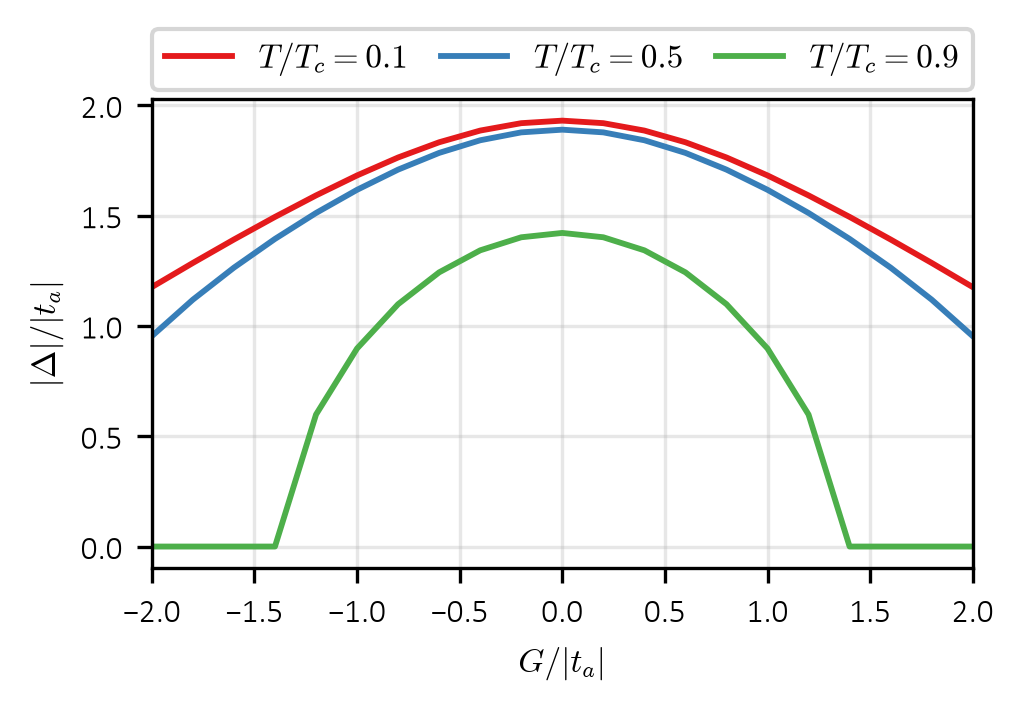

In [10]:
e0 = abs(ta)

h = 0.7
fig, ax = plt.subplots(
    figsize=(3.47412, h * 3.47412)
)

for j in tqdm(range(tr.size), desc="Plotting"):
    ax.plot(
        ga / e0,
        da[j] / e0,
        color=set1_list[j],
        linewidth=1.4,
        label=rf"$T/T_c={tr[j]:.1f}$",
    )

ax.set_xlim(ga[0] / e0, ga[-1] / e0)
ax.set_xlabel(r"$G/|t_a|$")
ax.set_ylabel(r"$|\Delta|/|t_a|$")

ax.grid(alpha=0.3)

ax.legend(
    bbox_to_anchor=(0, 1.02, 1, 0.2),
    loc="lower left",
    mode="expand",
    borderaxespad=0,
    ncol=3,
)

plt.tight_layout()
plt.show()

In [11]:
tba = np.array([-1.0, -0.7, -0.5, -0.3])
xn = np.linspace(0.1, 2.0, nt)
tca = np.empty(tba.size)

pq = eu.MFPars(
    v=v,
    n=n,
    uh=uh,
)

mua = np.full((tba.size, nt), np.nan)
dda = np.full_like(mua, np.nan)
mma = np.full_like(mua, np.nan)
oka = np.zeros((tba.size, nt), dtype=bool)


eca = np.full_like(mua, np.nan)
eva = np.full_like(mua, np.nan)


for j in tqdm(range(tba.size), desc="tb values"):
    tb = tba[j]

    bdq = eu.tb_2d(
        nk=nk,
        gap=gap,
        ta=ta,
        tb=float(tb),
    )

    tcq = eu.critical_temperature(
        bdq,
        pq,
        tlo=1.0e-4,
        thi=2.0,
        tol=1.0e-7,
        nmax=100,
        prog=False,

    )

    tca[j] = tcq

    d = 1.0
    m = 0.0

    for q in tqdm(
        range(nt),
        desc=rf"$t_b={tb:.1f}$",
        leave=False,
    ):
        sq = eu.solve_eq(
            bdq,
            pq,
            t=xn[q] * tcq,
            d=max(abs(d), 1.0e-2),
            m=m,
            mix=(0.15, 0.15),
            tol=1.0e-7,
            nmax=20000,
            chk=20,
            prog=False,
        )

        mua[j, q] = sq.mu
        dda[j, q] = abs(sq.d)
        mma[j, q] = sq.m
        oka[j, q] = sq.ok

        d = sq.d
        m = sq.m

        stq = ej.mf_state(bdq, pq, sq.d, sq.m)

        eca[j, q] = np.min(np.asarray(stq.e[0]))
        eva[j, q] = np.max(np.asarray(stq.e[1]))

logger.info(f"All converged: {np.all(oka)}")

for j in tqdm(range(tba.size), desc="Checking gap"):
    logger.info(
        f"tb={tba[j]:.2f}, "
        f"Ev={eva[j, 0]:.6f}, "
        f"mu={mua[j, 0]:.6f}, "
        f"Ec={eca[j, 0]:.6f}, "
        f"gap={eca[j, 0] - eva[j, 0]:.6f}"
    )

tb values:   0%|          | 0/4 [00:00<?, ?it/s]

$t_b=-1.0$:   0%|          | 0/30 [00:00<?, ?it/s]

$t_b=-0.7$:   0%|          | 0/30 [00:00<?, ?it/s]

$t_b=-0.5$:   0%|          | 0/30 [00:00<?, ?it/s]

$t_b=-0.3$:   0%|          | 0/30 [00:00<?, ?it/s]

[20:36:52] [INFO    ] All converged: True


Checking gap:   0%|          | 0/4 [00:00<?, ?it/s]

[20:36:52] [INFO    ] tb=-1.00, Ev=0.816720, mu=2.500000, Ec=4.183280, gap=3.366560
[20:36:52] [INFO    ] tb=-0.70, Ev=0.522459, mu=2.183954, Ec=3.831409, gap=3.308950
[20:36:52] [INFO    ] tb=-0.50, Ev=0.298192, mu=1.824287, Ec=3.311052, gap=3.012860
[20:36:52] [INFO    ] tb=-0.30, Ev=0.048464, mu=1.322031, Ec=2.452326, gap=2.403862


Plotting:   0%|          | 0/4 [00:00<?, ?it/s]

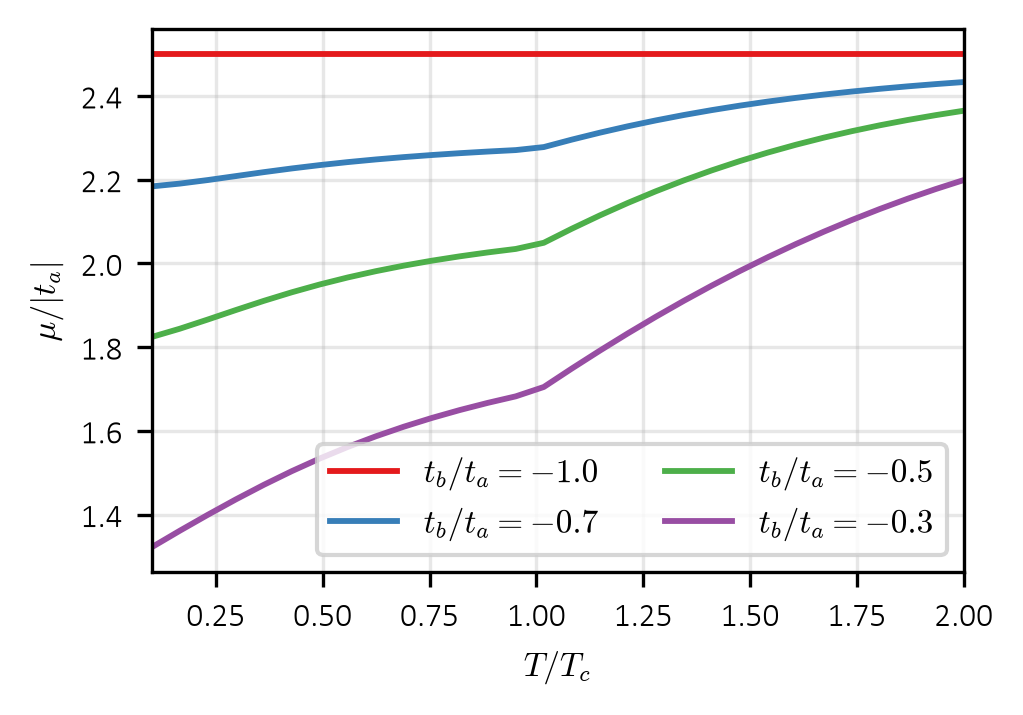

In [12]:
h = 0.7
fig, ax = plt.subplots(
    figsize=(3.47412, h * 3.47412)
)

for j in tqdm(range(tba.size), desc="Plotting"):
    ax.plot(
        xn,
        mua[j] / abs(ta),
        color=set1_list[j],
        linewidth=1.4,
        label=rf"$t_b/t_a={tba[j] / ta:.1f}$",
    )

ax.set_xlim(xn[0], xn[-1])
ax.set_xlabel(r"$T/T_c$")
ax.set_ylabel(r"$\mu/|t_a|$")

ax.grid(alpha=0.3)
ax.legend(
    ncol=2,
)

plt.tight_layout()
plt.show()

In [ ]:
nv = 50
ng = 50

va = np.linspace(0.1, 15.0, nv)
ga = np.linspace(0.0, 2.3, ng)

da = np.full((ng, nv), np.nan)
ma = np.full_like(da, np.nan)
mua = np.full_like(da, np.nan)
era = np.full_like(da, np.nan)
oka = np.zeros((ng, nv), dtype=bool)

# Seed for the highest V point
dh = 1.0
mh = 0.0

bar = tqdm(range(ng), desc="Gap rows")

for j in bar:
    g0 = ga[j]

    bdq = eu.tb_2d(
        nk=nk,
        gap=float(g0),
        ta=ta,
        tb=tb,
    )

    # Start each row from the ordered side
    d = max(abs(dh), 0.1)
    m = mh

    for i in tqdm(
        range(nv),
        desc="V sweep",
        leave=False,
    ):
        v0 = va[i]

        pq = eu.MFPars(
            v=float(v0),
            n=1.0,
            uh=float(v0),
        )

        sq = eu.solve_eq(
            bdq,
            pq,
            t=0.01 * tc,
            d=max(abs(d), 1.0e-6),
            m=m,
            mix=(0.15, 0.15),
            tol=1.0e-5,
            nmax=20000,
            chk=20,
            prog=False,
        )

        da[j, i] = abs(sq.d)
        ma[j, i] = sq.m
        mua[j, i] = sq.mu
        era[j, i] = sq.err
        oka[j, i] = sq.ok

        d = sq.d
        m = sq.m

        # Save the high-V seed for the next Gap row
        if i == nv - 1:
            dh = sq.d
            mh = sq.m

    bar.set_postfix(
        gap=f"{g0:.2f}",
        dmax=f"{np.nanmax(da[j]):.3f}",
        err=f"{np.nanmax(era[j]):.2e}",
    )

logger.info(f"All converged: {np.all(oka)}")
logger.info(f"Failed points: {np.count_nonzero(~oka)}")
logger.info(f"Largest error: {np.nanmax(era)}")

Gap rows:   0%|          | 0/50 [00:00<?, ?it/s]

V sweep:   0%|          | 0/50 [00:00<?, ?it/s]

V sweep:   0%|          | 0/50 [00:00<?, ?it/s]

V sweep:   0%|          | 0/50 [00:00<?, ?it/s]

V sweep:   0%|          | 0/50 [00:00<?, ?it/s]

...

V sweep:   0%|          | 0/50 [00:00<?, ?it/s]

V sweep:   0%|          | 0/50 [00:00<?, ?it/s]

V sweep:   0%|          | 0/50 [00:00<?, ?it/s]

V sweep:   0%|          | 0/50 [00:00<?, ?it/s]

[20:55:48] [INFO    ] All converged: False
[20:55:48] [INFO    ] Failed points: 11
[20:55:48] [INFO    ] Largest error: 4.480066395204374e-05


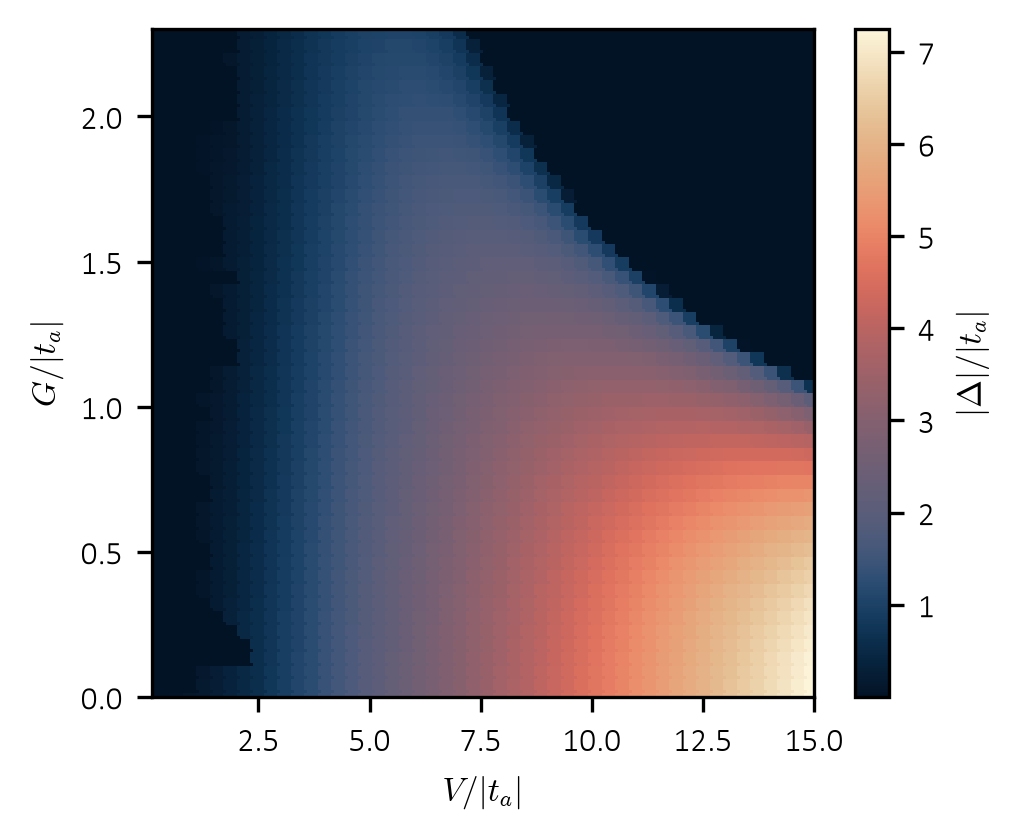

In [19]:
h = 0.82
fig, ax = plt.subplots(
    figsize=(3.47412, h * 3.47412)
)

im = ax.pcolormesh(
    va / abs(ta),
    ga / abs(ta),
    da / abs(ta),
    shading="auto",
    cmap=cmaps.lipari,
)
im.set_edgecolor("face")

ax.set_xlim(va[0] / abs(ta), va[-1] / abs(ta))
ax.set_ylim(ga[0] / abs(ta), ga[-1] / abs(ta))

ax.set_xlabel(r"$V/|t_a|$")
ax.set_ylabel(r"$G/|t_a|$")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(
    r"$|\Delta|/|t_a|$",
    rotation=90,
    labelpad=5,
)

plt.tight_layout()
plt.show()

In [23]:
vpa = np.array([2.0, 3.0, 4.0, 5.0])
tr = np.linspace(0.05, 1.2, 50)

tcva = np.full(vpa.size, np.nan)

da = np.full((vpa.size, tr.size), np.nan)
ma = np.full_like(da, np.nan)
mua = np.full_like(da, np.nan)
eca = np.full_like(da, np.nan)

cp = dict(eq["critical"])
cp["prog"] = False

bar = tqdm(range(vpa.size), desc="V values")

for j in bar:
    v0 = vpa[j]

    pq = eu.MFPars(
        v=float(v0),
        n=n,
        uh=float(v0),
    )

    tcq = eu.critical_temperature(
        bd,
        pq,
        **cp,
    )

    tcva[j] = tcq

    d = max(d0, 0.1)
    m = s0.m

    for q in tqdm(
        range(tr.size),
        desc=rf"$V/|t_a|={v0 / abs(ta):.1f}$",
        leave=False,
    ):
        t = tr[q] * tcq

        sq = eu.solve_eq(
            bd, pq, t=t,
            d=max(abs(d), 1.0e-4),
            m=m,
            **eq["solve"],
        )

        ec = (
            v0 * n / 2
            + (ta + tb) / (2 * (ta - tb))
            * (v0 * sq.m - gap)
        )

        da[j, q] = abs(sq.d)
        ma[j, q] = sq.m
        mua[j, q] = sq.mu
        eca[j, q] = ec

        d = sq.d
        m = sq.m

        bar.set_postfix(
            v=f"{v0:.1f}",
            tc=f"{tcq:.3f}",
            t=f"{tr[q]:.2f}",
            d=f"{abs(sq.d):.3e}",
        )

for j in tqdm(range(vpa.size), desc="Critical temperatures"):
    logger.info(
        f"V = {vpa[j]:.2f}, Tc = {tcva[j]:.8f}"
    )

V values:   0%|          | 0/4 [00:00<?, ?it/s]

$V/|t_a|=2.0$:   0%|          | 0/50 [00:00<?, ?it/s]

$V/|t_a|=3.0$:   0%|          | 0/50 [00:00<?, ?it/s]

$V/|t_a|=4.0$:   0%|          | 0/50 [00:00<?, ?it/s]

$V/|t_a|=5.0$:   0%|          | 0/50 [00:00<?, ?it/s]

Critical temperatures:   0%|          | 0/4 [00:00<?, ?it/s]

[21:14:57] [INFO    ] V = 2.00, Tc = 0.14474957
[21:14:57] [INFO    ] V = 3.00, Tc = 0.39084985
[21:14:57] [INFO    ] V = 4.00, Tc = 0.64982183
[21:14:57] [INFO    ] V = 5.00, Tc = 0.89205950


Plotting:   0%|          | 0/4 [00:00<?, ?it/s]

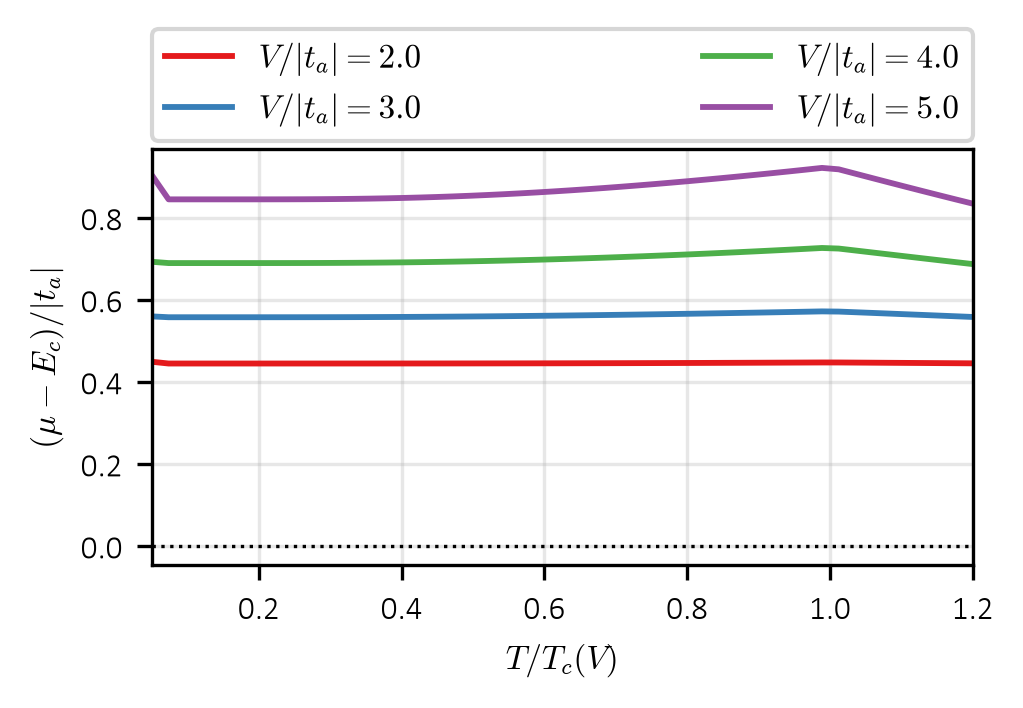

In [24]:
e0 = abs(ta)

h = 0.7
fig, ax = plt.subplots(
    figsize=(3.47412, h * 3.47412)
)

for j in tqdm(range(vpa.size), desc="Plotting"):
    ax.plot(
        tr,
        (mua[j] - eca[j]) / e0,
        color=set1_list[j],
        linewidth=1.4,
        label=rf"$V/|t_a|={vpa[j] / e0:.1f}$",
    )

ax.axhline(
    0.0,
    color="black",
    linestyle=":",
    linewidth=0.8,
)

ax.set_xlim(tr[0], tr[-1])
ax.set_xlabel(r"$T/T_c(V)$")
ax.set_ylabel(r"$(\mu-E_c)/|t_a|$")

ax.grid(alpha=0.3)

ax.legend(
    bbox_to_anchor=(0, 1.02, 1, 0.2),
    loc="lower left",
    mode="expand",
    borderaxespad=0,
    ncol=2,
)

plt.tight_layout()
plt.show()

Plotting:   0%|          | 0/4 [00:00<?, ?it/s]

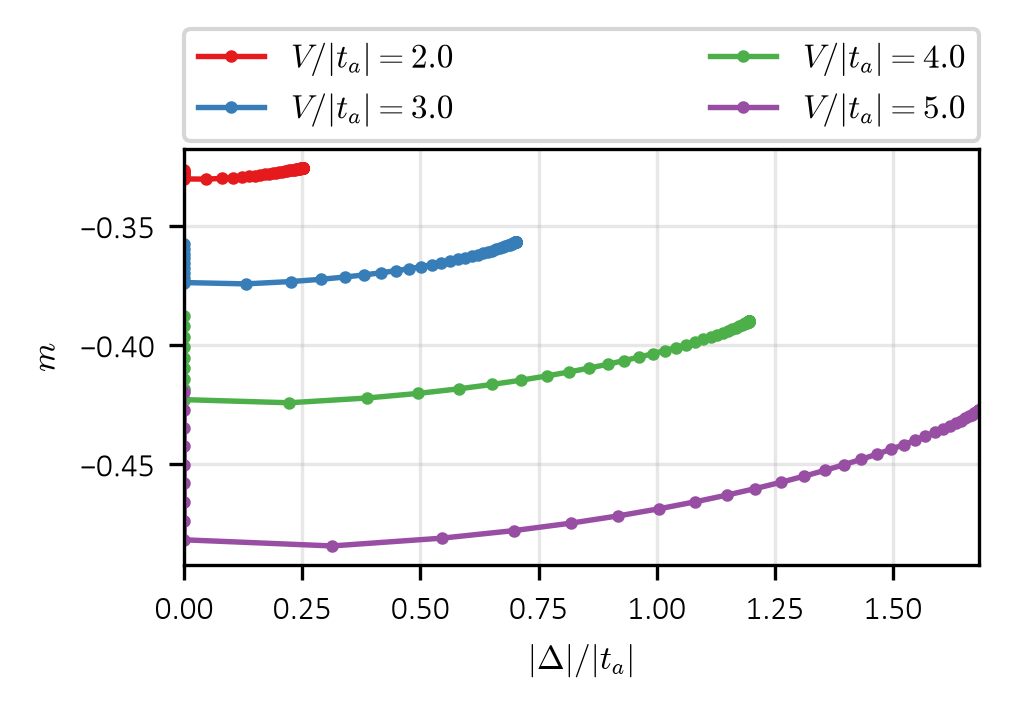

In [25]:
dx = da / e0

h = 0.7
fig, ax = plt.subplots(
    figsize=(3.47412, h * 3.47412)
)

for j in tqdm(range(vpa.size), desc="Plotting"):
    ax.plot(
        dx[j],
        ma[j],
        color=set1_list[j],
        linewidth=1.3,
        marker="o",
        markersize=2.0,
        label=rf"$V/|t_a|={vpa[j] / e0:.1f}$",
    )

ax.set_xlim(
    np.nanmin(dx),
    np.nanmax(dx),
)

ax.set_xlabel(r"$|\Delta|/|t_a|$")
ax.set_ylabel(r"$m$")

ax.grid(alpha=0.3)

ax.legend(
    bbox_to_anchor=(0, 1.02, 1, 0.2),
    loc="lower left",
    mode="expand",
    borderaxespad=0,
    ncol=2,
)

plt.tight_layout()
plt.show()

In [26]:
nv = 10
ng = 10
nr = 10
ntp = 10

va = np.linspace(0.1, 7.0, nv)
ga = np.linspace(0.0, 2.3, ng)
rba = np.linspace(-1.2, -0.1, nr)
tra = np.linspace(0.05, 1.5, ntp)

tfix = eq["initial"]["t"]
ds = max(0.1 * d0, 1.0e-3)

In [27]:
dtv = np.full((ntp, nv), np.nan)

dh = max(d0, ds)
mh = s0.m

bar = tqdm(range(ntp), desc="T-V map")

for j in bar:
    t = tra[j] * tc

    d = max(abs(dh), ds)
    m = mh

    for i in tqdm(
        range(nv - 1, -1, -1),
        desc="V sweep",
        leave=False,
    ):
        v0 = va[i]

        pq = eu.MFPars(
            v=float(v0),
            n=n,
            uh=uh,
        )

        sq = eu.solve_eq(
            bd, pq, t=t,
            d=max(abs(d), ds),
            m=m,
            **eq["solve"],
        )

        dtv[j, i] = abs(sq.d)

        d = sq.d
        m = sq.m

        if i == nv - 1:
            dh = sq.d
            mh = sq.m

    bar.set_postfix(
        t=f"{tra[j]:.2f}",
        dmax=f"{np.nanmax(dtv[j]):.3f}",
    )

T-V map:   0%|          | 0/10 [00:00<?, ?it/s]

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

...

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

In [28]:
dtg = np.full((ntp, ng), np.nan)

dh = max(d0, ds)
mh = s0.m

bar = tqdm(range(ntp), desc="T-G map")

for j in bar:
    t = tra[j] * tc

    d = max(abs(dh), ds)
    m = mh

    for i in tqdm(
        range(ng),
        desc="G sweep",
        leave=False,
    ):
        g0 = ga[i]

        bdq = eu.tb_2d(
            nk=nk,
            gap=float(g0),
            ta=ta,
            tb=tb,
        )

        sq = eu.solve_eq(
            bdq, p, t=t,
            d=max(abs(d), ds),
            m=m,
            **eq["solve"],
        )

        dtg[j, i] = abs(sq.d)

        d = sq.d
        m = sq.m

        if i == 0:
            dh = sq.d
            mh = sq.m

    bar.set_postfix(
        t=f"{tra[j]:.2f}",
        dmax=f"{np.nanmax(dtg[j]):.3f}",
    )

T-G map:   0%|          | 0/10 [00:00<?, ?it/s]

G sweep:   0%|          | 0/10 [00:00<?, ?it/s]

G sweep:   0%|          | 0/10 [00:00<?, ?it/s]

G sweep:   0%|          | 0/10 [00:00<?, ?it/s]

G sweep:   0%|          | 0/10 [00:00<?, ?it/s]

...

G sweep:   0%|          | 0/10 [00:00<?, ?it/s]

G sweep:   0%|          | 0/10 [00:00<?, ?it/s]

G sweep:   0%|          | 0/10 [00:00<?, ?it/s]

G sweep:   0%|          | 0/10 [00:00<?, ?it/s]

G sweep:   0%|          | 0/10 [00:00<?, ?it/s]

In [29]:
dgr = np.full((nr, ng), np.nan)

dh = max(d0, ds)
mh = s0.m

bar = tqdm(range(nr), desc="G-tb map")

for j in bar:
    r0 = rba[j]
    tb0 = r0 * ta

    d = max(abs(dh), ds)
    m = mh

    for i in tqdm(
        range(ng),
        desc="G sweep",
        leave=False,
    ):
        g0 = ga[i]

        bdq = eu.tb_2d(
            nk=nk,
            gap=float(g0),
            ta=ta,
            tb=float(tb0),
        )

        sq = eu.solve_eq(
            bdq, p, t=tfix,
            d=max(abs(d), ds),
            m=m,
            **eq["solve"],
        )

        dgr[j, i] = abs(sq.d)

        d = sq.d
        m = sq.m

        if i == 0:
            dh = sq.d
            mh = sq.m

    bar.set_postfix(
        tb=f"{r0:.2f}",
        dmax=f"{np.nanmax(dgr[j]):.3f}",
    )

G-tb map:   0%|          | 0/10 [00:00<?, ?it/s]

G sweep:   0%|          | 0/10 [00:00<?, ?it/s]

G sweep:   0%|          | 0/10 [00:00<?, ?it/s]

G sweep:   0%|          | 0/10 [00:00<?, ?it/s]

G sweep:   0%|          | 0/10 [00:00<?, ?it/s]

...

G sweep:   0%|          | 0/10 [00:00<?, ?it/s]

G sweep:   0%|          | 0/10 [00:00<?, ?it/s]

G sweep:   0%|          | 0/10 [00:00<?, ?it/s]

G sweep:   0%|          | 0/10 [00:00<?, ?it/s]

G sweep:   0%|          | 0/10 [00:00<?, ?it/s]

In [30]:
dvr = np.full((nr, nv), np.nan)

dh = max(d0, ds)
mh = s0.m

bar = tqdm(range(nr), desc="V-tb map")

for j in bar:
    r0 = rba[j]
    tb0 = r0 * ta

    bdq = eu.tb_2d(
        nk=nk,
        gap=gap,
        ta=ta,
        tb=float(tb0),
    )

    d = max(abs(dh), ds)
    m = mh

    for i in tqdm(
        range(nv - 1, -1, -1),
        desc="V sweep",
        leave=False,
    ):
        v0 = va[i]

        pq = eu.MFPars(
            v=float(v0),
            n=n,
            uh=uh,
        )

        sq = eu.solve_eq(
            bdq, pq, t=tfix,
            d=max(abs(d), ds),
            m=m,
            **eq["solve"],
        )

        dvr[j, i] = abs(sq.d)

        d = sq.d
        m = sq.m

        if i == nv - 1:
            dh = sq.d
            mh = sq.m

    bar.set_postfix(
        tb=f"{r0:.2f}",
        dmax=f"{np.nanmax(dvr[j]):.3f}",
    )

V-tb map:   0%|          | 0/10 [00:00<?, ?it/s]

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

...

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

V sweep:   0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_59852/3786846393.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


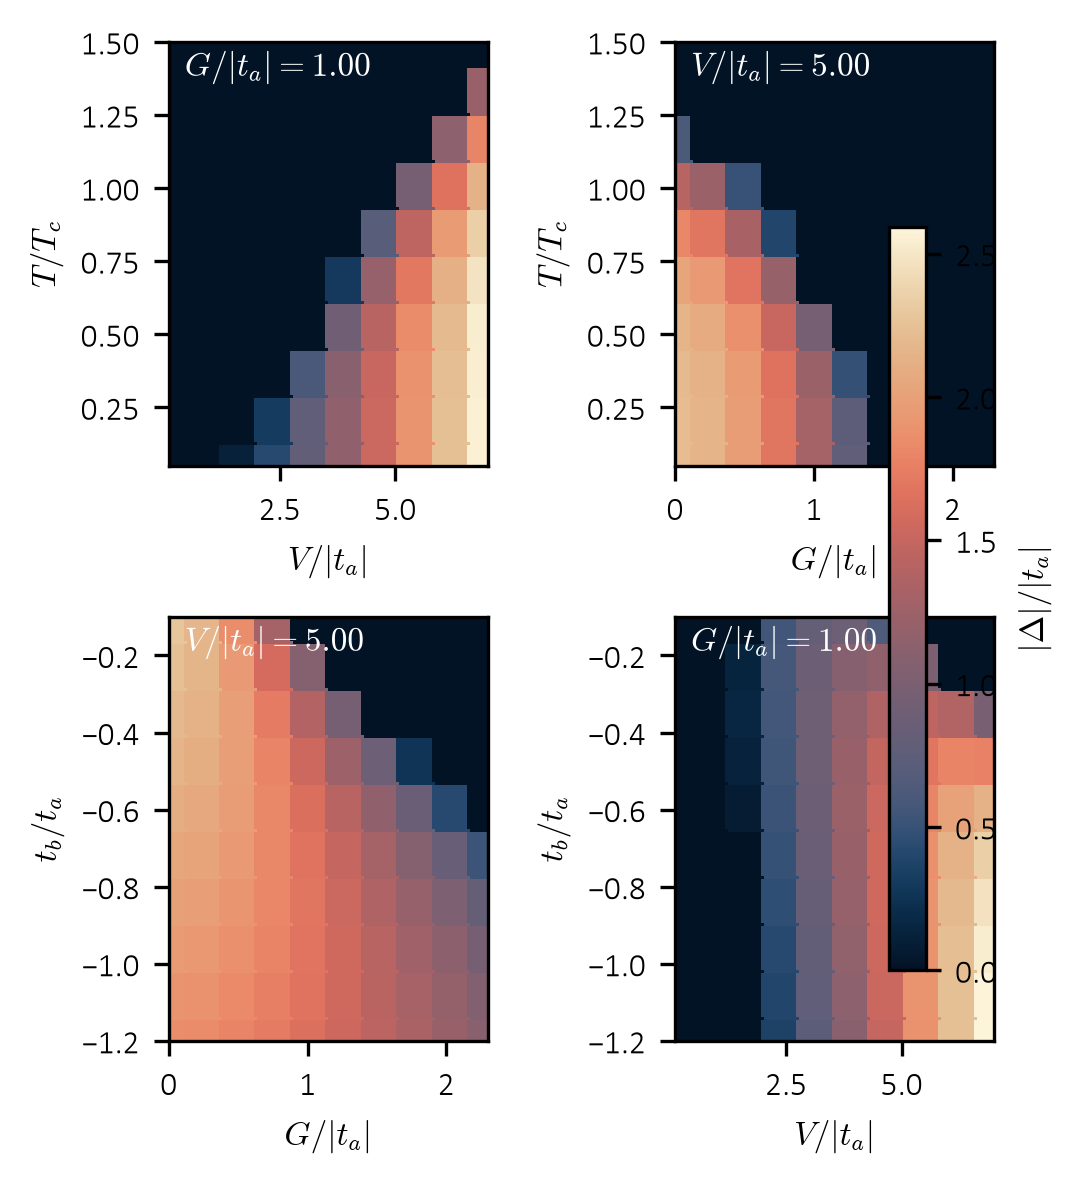

In [31]:
e0 = abs(ta)

dm = np.nanmax(
    np.stack((
        np.nanmax(dtv),
        np.nanmax(dtg),
        np.nanmax(dgr),
        np.nanmax(dvr),
    ))
) / e0

h = 1.15
fig, ax = plt.subplots(
    2, 2,
    figsize=(3.47412, h * 3.47412),
)

im0 = ax[0, 0].pcolormesh(
    va / e0,
    tra,
    dtv / e0,
    shading="auto",
    cmap=cmaps.lipari,
    vmin=0.0,
    vmax=dm,
)
im0.set_edgecolor("face")

im1 = ax[0, 1].pcolormesh(
    ga / e0,
    tra,
    dtg / e0,
    shading="auto",
    cmap=cmaps.lipari,
    vmin=0.0,
    vmax=dm,
)
im1.set_edgecolor("face")

im2 = ax[1, 0].pcolormesh(
    ga / e0,
    rba,
    dgr / e0,
    shading="auto",
    cmap=cmaps.lipari,
    vmin=0.0,
    vmax=dm,
)
im2.set_edgecolor("face")

im3 = ax[1, 1].pcolormesh(
    va / e0,
    rba,
    dvr / e0,
    shading="auto",
    cmap=cmaps.lipari,
    vmin=0.0,
    vmax=dm,
)
im3.set_edgecolor("face")

ax[0, 0].set_xlim(va[0] / e0, va[-1] / e0)
ax[0, 0].set_ylim(tra[0], tra[-1])
ax[0, 0].set_xlabel(r"$V/|t_a|$")
ax[0, 0].set_ylabel(r"$T/T_c$")

ax[0, 1].set_xlim(ga[0] / e0, ga[-1] / e0)
ax[0, 1].set_ylim(tra[0], tra[-1])
ax[0, 1].set_xlabel(r"$G/|t_a|$")
ax[0, 1].set_ylabel(r"$T/T_c$")

ax[1, 0].set_xlim(ga[0] / e0, ga[-1] / e0)
ax[1, 0].set_ylim(rba[0], rba[-1])
ax[1, 0].set_xlabel(r"$G/|t_a|$")
ax[1, 0].set_ylabel(r"$t_b/t_a$")

ax[1, 1].set_xlim(va[0] / e0, va[-1] / e0)
ax[1, 1].set_ylim(rba[0], rba[-1])
ax[1, 1].set_xlabel(r"$V/|t_a|$")
ax[1, 1].set_ylabel(r"$t_b/t_a$")

ax[0, 0].text(
    0.05, 0.92,
    rf"$G/|t_a|={gap / e0:.2f}$",
    transform=ax[0, 0].transAxes,
    color="white",
)

ax[0, 1].text(
    0.05, 0.92,
    rf"$V/|t_a|={v / e0:.2f}$",
    transform=ax[0, 1].transAxes,
    color="white",
)

ax[1, 0].text(
    0.05, 0.92,
    rf"$V/|t_a|={v / e0:.2f}$",
    transform=ax[1, 0].transAxes,
    color="white",
)

ax[1, 1].text(
    0.05, 0.92,
    rf"$G/|t_a|={gap / e0:.2f}$",
    transform=ax[1, 1].transAxes,
    color="white",
)

cbar = fig.colorbar(
    im3,
    ax=ax,
    fraction=0.046,
    pad=0.04,
)

cbar.set_label(
    r"$|\Delta|/|t_a|$",
    rotation=90,
    labelpad=5,
)

plt.tight_layout()
plt.show()